# Chapter 3 Investigation Notebook: The Business of Pizza (COMPLETE)

<div class="teacher-note">

#### Summary of Notebook:

In this lesson, students will model the price of pizza using the <code>Toppings</code> model. Intuitively, as the number of toppings goes up, so does the average price of a pizza. We chose this example because the units (pizza toppings, and price in dollars) are fairly straightforward to understand while trying to make sense of $b_0$ and $b_1$.

#### Highlighted Skills and Concepts:
- Fitting a regression model
- Interpreting the model estimates
- Making predictions with the model
- Comparing the residuals from the empty model to the residuals of the regression model

***Optional Lesson Launch:***
Give each student one line from the data frame (use [this handout](https://docs.google.com/document/d/1XXefq-w4JGI8FcDqR-iZfXMhEKeB5Hht6-OUzVsGAFI/edit?usp=sharing))
Then have students discuss with a partner/group: 
- What pizza did you get?
- What’s the name of the restaurant? 
- Where is it from? 
- How many toppings? 
- How much did it cost?
- Would you buy this pizza? Why or why not?

***Optional Lesson Idea:*** 

If you are interested in personalizing the lesson and giving students practice collecting data, you may opt to have students add to the dataset beforehand by looking up the data for their own local pizza shops and adding in the info for the variables directly into the spreadsheet (download it with the csv link and turn it into your own Google Sheet document, then publish it and replace the link below) or by adding the cases directly into the R data frame. Note that this may affect use of handouts with printed graphs, as they may not match your data. Feel free to modify them, if needed. **Lizi is working on making a HI dataset!**
</div>

In [1]:
# Load the CourseKata library
suppressPackageStartupMessages({
    library(coursekata)
})

# set styles
css <- suppressWarnings(readLines("https://raw.githubusercontent.com/jimstigler/jupyter/master/ck_jupyter_styles_v2.css"))
IRdisplay::display_html(sprintf('<style>%s</style>', paste(css, collapse = "\n")))

Pizza <- read.csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vTdYRrZRqsTy4QkODio8HzpNEvaeTIR0IHsWWJfe5EiftEcAKdLwayL1_lFQVVzHKbMQqPaFIRJVzH5/pub?gid=904658551&single=true&output=csv", header = TRUE)

Are you a pizza consumer? Did you know that, globally, the pizza industry is worth $145 billion, and, on any given day, [13% of the US population consumes pizza](https://na-pizza.com/pizza-industry-revenue-in-the-u-s-around-the-world/)?

<img src="https://imgur.com/Bg5Rvqh.png" title="pepperoni pizza" width=500>

**Opening Discussion:** What are your ideas about what makes a pizza great, or what makes a pizza worth more? What makes you willing to pay more for a pizza?

To explore this question, let's dig into some data from pizza places in California. The data frame `Pizza` has data on 108 pizzas sold by 18 different places (prices were gathered from their websites):

- `Place` The name of the pizza place
- `Size` The size of the pizza
- `Name` The descriptive name of the pizza (for that specific combination of toppings)
- `Price` The price of the pizza
- `Toppings` The number of toppings on the pizza (0 toppings equates to a cheese pizza)
- `County` The county in California that the shop is located (Los Angeles, San Francisco, San Diego)
- `ZipCode` The zip code in California where the shop is located
- `MedianIncome_2020` The median income in 2020 for the zip code of the pizza shop (according to this source: https://www.incomebyzipcode.com/)
- `Website` The website link for the pizza place

## 1.0 Explore Variation in `Price`

### 1.1 Take a look at the `Pizza` data frame. 
Write some code to look at the data frame. Then answer the following questions: 
- What are the cases? 
- How many variables are there? 
- Does anything stand out to you? 
- Do you have any questions about the data frame? 


In [ ]:
# write some code here

*type your response here* 
- Cases: 
- Variables: 
- Noticings: 
- Wonderings: 

In [4]:
# sample response

head(Pizza)
glimpse(Pizza)

,Place,Size,Name,Price,Toppings,County,ZipCode,MedianIncome_2020,YelpStars,NumReviews,Website
,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<int>,<int>,<dbl>,<int>,<chr>
1,Extreme Pizza,Small,Cheese,8.45,0,San Francisco,94103,75764,3.0,457,http://extremepizza.com/
2,The Kitchen Pasadena,Small,Cheese,9.95,0,Los Angeles,91103,71230,3.5,550,https://www.thekitchenpasadena.com/
3,Pachino Pizzeria,Medium,Cheese,10.00,0,San Francisco,94104,51500,4.0,584,"https://www.google.com/maps/place/Pachino+Pizzeria/@37.7911234,-122.4061028,17z/data=!3m1!4b1!4m5!3m4!1s0x8085808a29ffd695:0xa59a74fb991523c0!8m2!3d37.7911234!4d-122.4039141?authuser=0&hl=en"
4,Rosaria's Pizza,Small,Cheese,10.50,0,San Diego,92115,51636,4.0,155,https://slicelife.com/restaurants/ca/san-diego/92115/rosaria-s-pizza/menu
5,Extreme Pizza,Small,Ghost Wave,10.95,4,San Francisco,94103,75764,3.0,457,http://extremepizza.com/
6,Leona's Cucina Italiana,Small,Cheese,11.50,0,San Diego,92105,43282,4.5,192,https://www.leonascucinaitaliana.com/


Rows: 108
Columns: 11
$ Place             <chr> "Extreme Pizza", "The Kitchen Pasadena", "Pachino Pi…
$ Size              <chr> "Small", "Small", "Medium", "Small", "Small", "Small…
$ Name              <chr> "Cheese", "Cheese", "Cheese", "Cheese", "Ghost Wave"…
$ Price             <dbl> 8.45, 9.95, 10.00, 10.50, 10.95, 11.50, 11.99, 12.00…
$ Toppings          <int> 0, 0, 0, 0, 4, 0, 2, 0, 5, 5, 0, 4, 3, 5, 0, 2, 4, 0…
$ County            <chr> "San Francisco", "Los Angeles", "San Francisco", "Sa…
$ ZipCode           <int> 94103, 91103, 94104, 92115, 94103, 92105, 90201, 900…
$ MedianIncome_2020 <int> 75764, 71230, 51500, 51636, 75764, 43282, 44045, 652…
$ YelpStars         <dbl> 3.0, 3.5, 4.0, 4.0, 3.0, 4.5, 4.5, 4.0, 3.5, 4.0, 4.…
$ NumReviews        <int> 457, 550, 584, 155, 457, 192, 465, 509, 550, 3, 584,…
$ Website           <chr> "http://extremepizza.com/", "https://www.thekitchenp…


<div class="teacher-note">

**Sample Response**

- The cases are pizzas.
- There are 11 variables 
- I notice that some of the pizzas are really expensive
- I wonder if there are expensive pizzas with really low reviews. 
    
</div>

### 1.2 Make a visualization for the hypothesis, `Price` $= f($ `Toppings`$) +$ other stuff  

In [ ]:
#write some code here

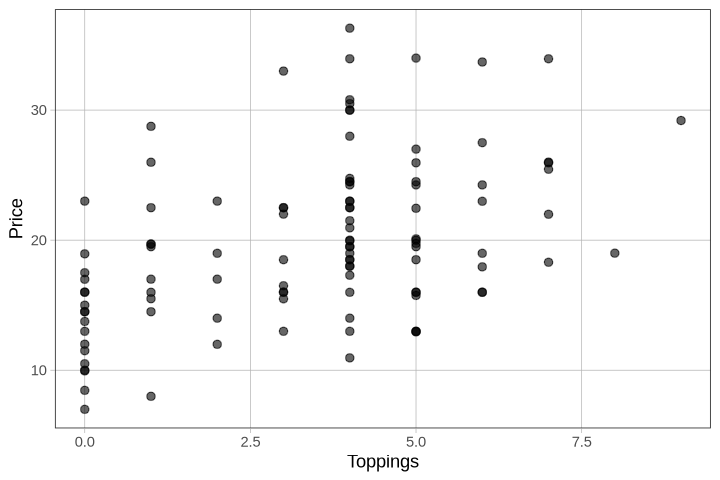

In [6]:
# COMPLETE
gf_point(Price ~ Toppings, data = Pizza)

### Based on the visualization, describe the relationship between `Price` and `Toppings`.   

*type your response here*

<div class="teacher-note">

**Sample Respone:** The more toppings, the more expensive the pizza. 
</div>

### 1.3 Experiment with adding another variable to your scatter plot.  

In [ ]:
#write some code here

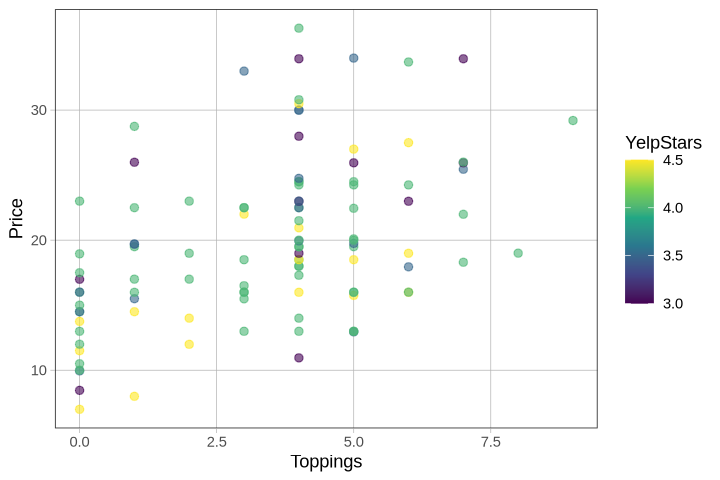

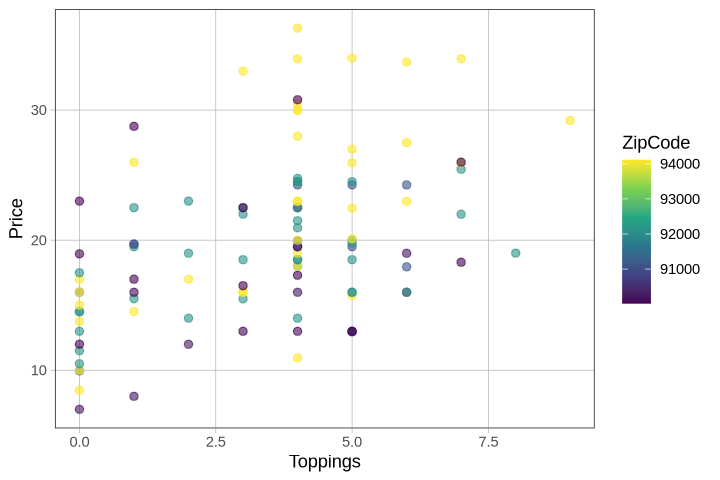

In [8]:
# sample responses
gf_point(Price ~ Toppings, data = Pizza, color = ~YelpStars)

gf_point(Price ~ Toppings, data = Pizza, color = ~ZipCode)

### 1.4 What does each dot represent? Why are the dots less "scattered" and line up vertically?

*type your response here*

<div class="teacher-note">

**Sample Response**

Each dot represents the <code>Price</code> and the number of <code>Toppings</code> for each pizza.

The dots are less scattered because all the toppings are whole numbers, and there aren't any increments between that (e.g, there aren't any pizzas with 2.5 toppings), so the cases just stack up along the whole-number units.

We could use a jitter plot if we would like to see them spread out a little more.
    
</div>

## 2.0 Model Variation: The `Toppings` Model

### 2.1 What is the empty model?
Create the empty model and graph it on a scatter plot. 

In [ ]:
# write some code here 


#store the empty model 
empty_model <- 

#graph the empty model 

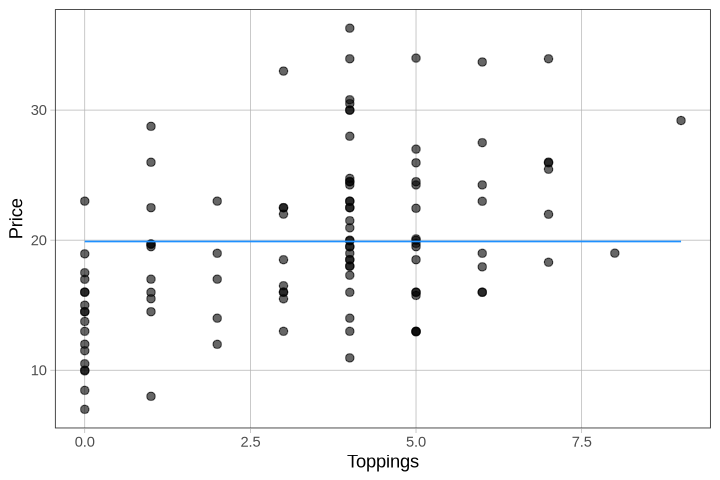

In [25]:
# COMPLETE VERSION

Y <- Pizza$Price
empty_model <- function(X){mean(Y)}

gf_point(Price ~ Toppings, data = Pizza) %>%
    gf_function(empty_model, color = "dodgerblue")

### 2.2 Find the equation for the best Toppings model and write it in GLM notation:

$Y_i = b_0 + b_1(X_i) + e_i$

In [ ]:
# write some code here 

# find the best model

# store your model 
b0 <- 
b1 <- 
toppings_model <- 

In [65]:
# COMPLETE 

# find the best model
lm(Price ~ Toppings, data = Pizza)

# store your model 
b0 <- 15.428
b1 <- 1.316
toppings_model <- function(X){b0 + b1*X}


Call:
lm(formula = Price ~ Toppings, data = Pizza)

Coefficients:
(Intercept)     Toppings  
     15.428        1.316  


*write your equation here*

<div class="teacher-note">

**Sample Response**

$Price = 15.43 + 1.32(Toppings) + error$

OR

$Y_i = 15.43 + 1.32(X_i) + error$

</div>

### 2.3 Find what the `toppings_model` will predict for each pizza.

In [16]:
# COMPLETE 
X <- Pizza$Toppings
predictions <- toppings_model(X)
predictions

[1]   1.316   1.316   1.316   1.316  63.028   1.316  32.172   1.316  78.456
 [10]  78.456   1.316  63.028  47.600  78.456   1.316  32.172  63.028   1.316
 [19]   1.316  16.744   1.316  47.600  16.744  78.456  78.456  63.028  16.744
 [28]  93.884   1.316   1.316  78.456  47.600  93.884  47.600  47.600   1.316
 [37]  16.744  32.172  63.028   1.316  93.884  63.028  63.028 109.312  63.028
 [46]  63.028  47.600  78.456   1.316  93.884  32.172  63.028 124.740  63.028
 [55]  78.456  16.744  63.028  16.744  16.744  78.456  63.028  78.456  63.028
 [64]  78.456  63.028  63.028 109.312  47.600  78.456  47.600  16.744  47.600
 [73]  63.028  63.028  63.028  93.884   1.316  32.172  63.028  93.884  78.456
 [82]  63.028  78.456  63.028  63.028  63.028 109.312 109.312  78.456  16.744
 [91] 109.312  78.456  93.884  63.028  16.744 140.168  63.028  63.028  63.028
[100]  63.028  47.600  93.884  63.028 109.312  78.456  63.028   1.316  16.744

### 2.4 Add the model's predictions as dots to the visualization in red. Then add in the `toppings_model` in orange.

In [ ]:
# write some code here 



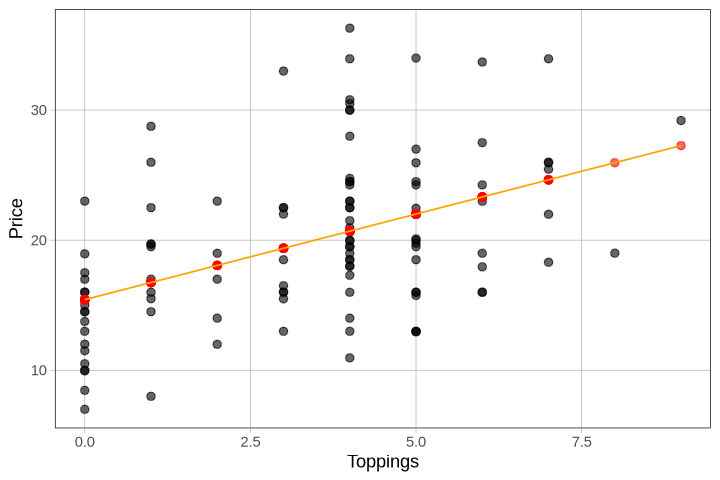

In [23]:
# COMPLETE 
gf_point(Price ~ Toppings, data=Pizza) %>% 
    gf_point(toppings_model(X) ~ X, color = "red") %>%
    gf_function(toppings_model, color = "orange")

<div class="teacher-note">

**Teacher Note:** Here, we have them add the predictions as dots as well as the regression line as a way of demonstrating the fact that a line is just a bunch of points, and the regression line is just a bunch of continuous model predictions.

</div>

### 2.5 What is $b_0$? What does it mean in this context? Where do you see it in the visualization?

<div class="teacher-note">

**Sample Response**

$b_0$ = 15.43. This means that the average price for a pizza with 0 toppings is about $15.43.

We can see this in our visualization along the y-axis at 15.43 (the y-intercept of the regression line).

</div>

### 2.6 What is $b_1$? What does it mean in this context? Where do you see it in the visualization?

<div class="teacher-note">

**Sample Response**

$b_1$ = 1.32. This means that for every additional topping we add \$1.32 to $b_0$, or the base price of a pizza ($15.43).

We can see this in our visualization as the slope of the line (every additional increment starting from the y-intercept).

</div>

### 2.7 According to the model, what would be the cost of a pizza with 1 topping? How about 5 toppings? 20 toppings? 

In [ ]:
# you can use R as a calculator 

In [ ]:
# COMPLETE 

# Possible strategy
15.43 + (1.32 * 1)
15.43 + (1.32 * 5) 
15.43 + (1.32 * 20)

*Write your predictions in function notation here*

<div class="teacher-note">

**Sample Response**

- 1 topping --> f(1) = 16.75
- 5 toppings --> f(5) = 22.03
- 20 toppings --> f(20) = 41.83


**Teacher Note:** You may want to ask about the reasonability of predicting a pizza with 20 toppings, as well as making predictions that go beyond the limits of our current data (extrapolation).

</div>

## 3.0 Evaluate the Models

### 3.1 How does the `toppings_model` compare with the `empty_model`? 
Let's take a look at our visualization with the regression model again, but this time, add in the empty model in blue below. 

In [ ]:
# write some code here

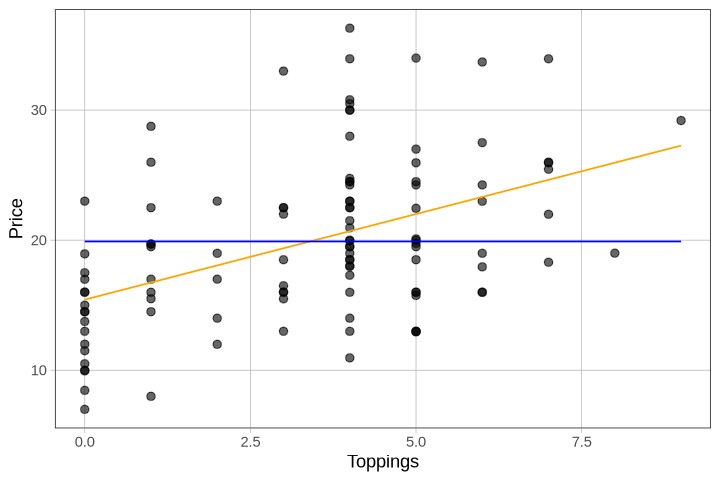

In [26]:
# COMPLETE

gf_point(Price ~ Toppings, data = Pizza)%>%
    gf_function(toppings_model, color="orange") %>%
    gf_function(empty_model, color = "blue")

### 3.2 Run the visualization below. All the orange dots are the pizzas from Te Amo Pizza in Los Angeles. 

For the two-topping pizza, which model is better, the empty model or the regression model? Explain.

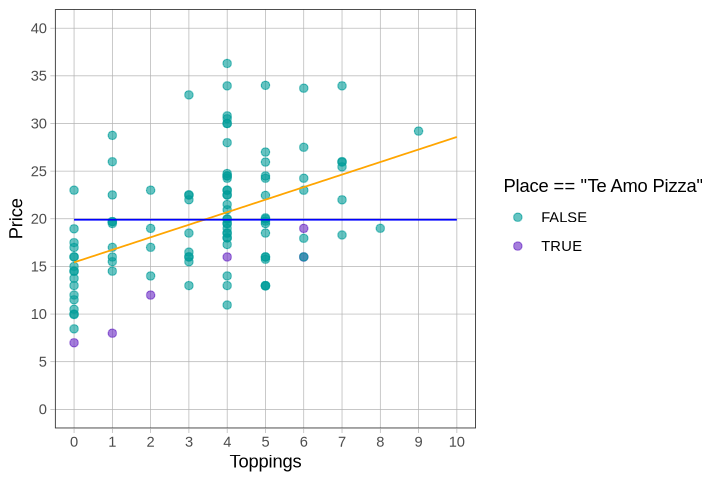

In [42]:
gf_point(Price ~ Toppings, data = Pizza, color = ~ Place == "Te Amo Pizza") %>%
    gf_function(toppings_model, color="orange") %>%
    gf_function(empty_model, color = "blue")+
    scale_x_continuous(limits = c(0, 10), breaks = seq(0, 10, 1)) +
    scale_y_continuous(limits = c(0, 40), breaks = seq(0, 40, 5))

*type your response here*

<div class="teacher-note">

**Sample Responses**

The regression model is better, because....

- it makes a better prediction.
- it has a smaller residual.
- the distance between the actual pizza and the regression model is smaller than the distance to the empty model.

You can see that the price goes up per topping for Te Amo Pizza pizzas at a similar rate to the regression line.

</div>

### 3.3 Are there any pizzas from Te Amo where the empty model is a better predictor of its price? Explain.

*type your response here*

<div class="teacher-note">

**Sample Response**

There are two pizzas (4 and 6 toppings) that are closer to the empty model's prediction than the regression line.

</div>

### 3.4 Explain how each model balances the residuals.

*type your response here*

<div class="teacher-note">

**Sample Response**

The empty model balances the residuals of only the outcome variable, <code>Price</code>, because the mean is the point where the positive residuals are balanced by the negative residuals.

The regression model balances the residuals of both variables, <code>Price</code> and <code>Toppings</code>, because it is also a balance point, similar to the mean, where the positive residuals are equally balanced by the negative residuals. 


In other words, for all the error above the model, there is an equal amount of error below the model.

</div>

### 3.5 Find and interpret the RMSE for each model. 

In [ ]:
# write some code here 

*type your response here*

In [61]:
# COMPLETE
rmse(Y, toppings_model(X))

rmse(Y, empty_model(X))

[1] 5.697693

[1] 6.244873

<div class="teacher-note">

**Sample Response:** On average, the <code>toppings_model</code> predicted price is about \$5.70 off from the actual price and the <code>empty_model</code> predicted price is about \$6.24 off from the actual price. This means the <code>toppings_model</code> is a better fit than the <code>empty_model</code>. 

</div>

### 3.6 Find and interpret the PRE for the `toppings_model`. 

In [ ]:
# write some code here 

*type your response here*

In [67]:
# COMPLETE
sse <- sse(Y, toppings_model(X))
sst <- sse(Y, empty_model(X))

(sst - sse)/sst

[1] 0.2145461

<div class="teacher-note">

**Sample Response:** The <code>toppings_model</code> reduced error by 21.5% compared to just using the mean price/empty model. 


</div>

## 4.0 Comparing Cities 
Our data frame includes pizza restuarants from three cities: Los Angeles, San Francisco, and San Diego. Let's compare pizza price from these three cities. 

### 4.1 Make a scatter plot (`Price ~ Toppings`) and color the points based on `County`. 

In [ ]:
# write some code here

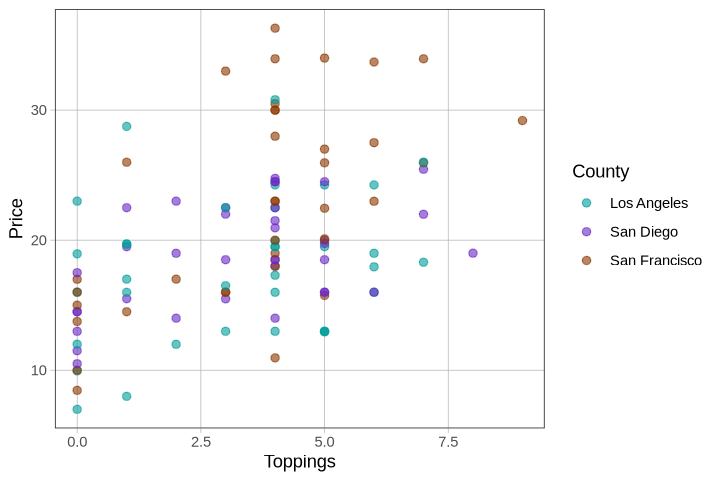

In [68]:
# COMPLETE 

gf_point(Price ~ Toppings, data = Pizza, color = ~County)

### What patterns do you see in the new visualization? 

*type your response here*

<div class="teacher-note">

**Sample Response:** SF seems to have more expensive pizzas. LA and SD seem pretty similar, maybe with LA being a little cheaper. 

**Teacher Note:** Students might have a hard time seeing any clear patterns, but they might be able to see what city has the most expensive pizza and the least expensive pizza. 

</div>

### 4.2 Modeling each city

#### 4.2a Run the code below to create three new data sets: 
1) `LA`: all of the pizza restaurants in the `County`, Los Angeles
2) `SF`: all of the pizza restaurants in the `County`, San Francisco
3) `SD`: all of the pizza restaurants in the `County`, San Diego

In [44]:
LA <- filter(Pizza, County == "Los Angeles")
SF <- filter(Pizza, County == "San Francisco")
SD <- filter(Pizza, County == "San Diego")

#### 4.2b Now let's fine the best fitting linear function for `LA`.

Note: if you store your intercept and slope values, name them differntly for each model (ex: `LAslope` or `SD_b1`)

In [ ]:
# find the best fitting linear model 

# store the model 

LA_model <- 

In [53]:
# COMPLETE 
lm(Price ~ Toppings, data = LA)
LAb0 <- 15.7106
LAb1 <- 0.7014

LA_model <- function(X){LAb0 + LAb1*X}


Call:
lm(formula = Price ~ Toppings, data = LA)

Coefficients:
(Intercept)     Toppings  
    15.7106       0.7014  


#### 4.2c Repeat for `SF`.

In [57]:
lm(Price ~ Toppings, data = SF)
SFb0 <- 15.208
SFb1 <- 2.094

SF_model <- function(X){SFb0 + SFb1*X}


Call:
lm(formula = Price ~ Toppings, data = SF)

Coefficients:
(Intercept)     Toppings  
     15.208        2.094  


#### 4.2d Repeat for `SD`.

In [55]:
lm(Price ~ Toppings, data = SD)
SDb0 <- 15.9054
SDb1 <- 0.8886

SD_model <- function(X){SDb0 + SDb1*X}


Call:
lm(formula = Price ~ Toppings, data = SD)

Coefficients:
(Intercept)     Toppings  
    15.9054       0.8886  


### 4.3 Write each of your models in GLM notation below. 

LA_model: 

SF_model: 

SD_model: 


<div class="teacher-note">

**Sample Response:**

LA_model: $Price = 15.7106 + 0.7014(Toppings) + error$ 

SF_model: $Price = 15.208 + 2.094(Toppings) + error$ 

SD_model: $Price = 15.9054 + 0.8886(Toppings) + error$ 


### 4.4 Graph each model on a scatter plot with the `Pizza` data frame. 
Make each model a different color.   

In [ ]:
# write some code here

*Write a color key for your graph here*  

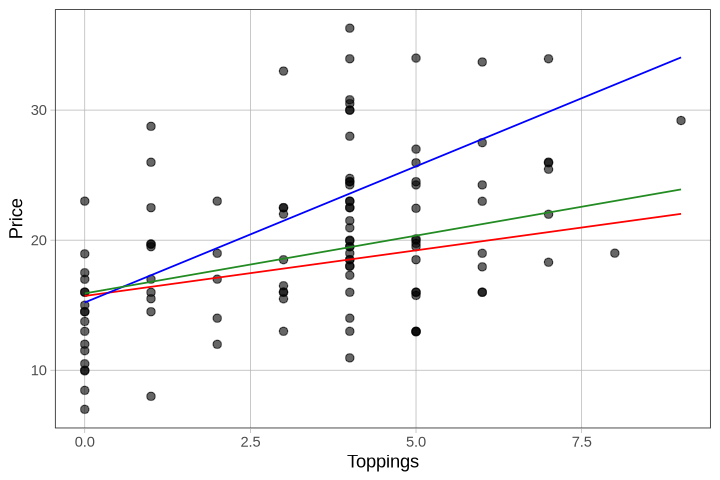

In [58]:
# COMPLETE 
gf_point(Price ~ Toppings, data = Pizza) %>%
    gf_function(LA_model, color = "red") %>%
    gf_function(SF_model, color = "blue") %>%
    gf_function(SD_model, color = "forestgreen") 

<div class="teacher-note">

**Sample Response:** red = Los Angeles, green = San Diego, blue = San Francisco 

### 4.4 Based on your graph and models, compare and constrast the pizza prices for each city. 
Use specifics from your models and justify your claims based on the graph.  

*type your response here*

<div class="teacher-note">

**Sample Response:** 
- They all have relatively the same price for a 0 topping pizza (around $15), but SF predicts the cheapest 0 topping pizza. In the graph, all three models start close together on the y-axis. 
- San Diego and Los Angeles are priced similarly -- their slopes are close together (LA with \$0.70 for each additional topping and SD with \$0.89 for each additional topping.) The lines are close togeher, but San Diego is a little higher (more expensive) than LA. 
- San Francisco has the most expensive (predicted) pizzas. Even though it starts very close to LA and SD, the slope is much higher (\$2.09 for each additional topping). This means the blue line is above the other two models and much steeper. 
- I wouldn't get pizza in SF because it's so expensive! 

</div>

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=69160fbc-ed07-4747-a631-40af8243d52c' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>